# End-to-End Portfolio Optimization — GMV with CNN-GARCH

**Goal**: Replace inverse-variance weighting with a full **Global Minimum Variance (GMV)** optimization,
using CNN-GARCH predicted volatilities combined with historical rolling correlations.

## Formula
$$\Sigma(t) = D(t) \cdot \text{Corr}_{90d}(t) \cdot D(t), \quad D(t) = \text{diag}(\sigma_{\text{NN}}(t))$$
$$w(t) = \arg\min_{w} \; w^\top \Sigma(t) w \quad \text{s.t.} \; \sum w_i = 1, \; w_i \geq 0, \; w_i \leq 10\%$$

## Strategies compared
1. **Equal-Weight** (1/N baseline)
2. **Inverse-Variance NN** (from Portfolio.ipynb)
3. **GMV-GARCH** — GARCH(1,1) vols + rolling correlations
4. **GMV-NN** ← new method — CNN-GARCH vols + rolling correlations

Inspired by: *Bongiorno et al. (2025) — End-to-End Large Portfolio Optimization*

In [ ]:
from __future__ import annotations
import warnings, sys, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import cvxpy as cp

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')   # access model.py and data_stocks_WIKI_price.py

from model import HybridGarch
from data_stocks_WIKI_price import get_cleaned_data
from rienet import CorrelationEigenTransformLayer

print(f'TensorFlow {tf.__version__} | NumPy {np.__version__} | cvxpy {cp.__version__}')

In [ ]:
pip install rienet

In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
FILE_PATH   = r'C:/Users/karim/OneDrive/Documents/Msc AI/Finance/TP/WIKI_PRICES_212b326a081eacca455e13140d7bb9db.zip'
CHECKPOINT  = r'../finetune_real_zeroaware_r2min1e8_best.weights.h5'

WINDOW_SIZE = 90      # rolling window — CNN input & correlation window
N_STOCKS    = 50
TRAIN_RATIO = 0.70
ANNUALIZE   = 252
MAX_WEIGHT  = 0.10    # 10% cap per stock (3 x 1/N for N=30)

print(f'Window : {WINDOW_SIZE} | Max weight : {MAX_WEIGHT:.0%}')

Window : 90 | Max weight : 10%


## 1. Data Loading

In [6]:
returns_df_full = get_cleaned_data(FILE_PATH)
print(f'Full universe : {returns_df_full.shape[0]} days x {returns_df_full.shape[1]} stocks')
print(f'Date range    : {returns_df_full.index[0].date()} -> {returns_df_full.index[-1].date()}')

# Select first N_STOCKS (same as Portfolio.ipynb)
selected   = returns_df_full.columns[:N_STOCKS].tolist()
returns_df = returns_df_full[selected].copy()
print(f'\nPortfolio : {N_STOCKS} stocks -> {selected[:5]} ...')

[get_cleaned_data] Universe after filters : 1338 stocks (price≥$3.0 on 2012-10-04, max consec zeros ≤ 20)
Full universe : 4585 days x 1338 stocks
Date range    : 2000-01-04 -> 2018-03-27

Portfolio : 50 stocks -> ['A', 'AAN', 'AAON', 'AAPL', 'ABAX'] ...


## 2. Train / Test Split

In [7]:
n_total   = len(returns_df)
split_idx = int(TRAIN_RATIO * n_total)
start_t   = max(WINDOW_SIZE, split_idx)

returns_train = returns_df.iloc[:split_idx]
returns_test  = returns_df.iloc[split_idx:]
test_dates    = returns_df.index[start_t:]

returns_arr  = returns_df.values.astype(np.float32)   # [T, N]
train_means  = returns_train.mean().values.astype(np.float32)
train_stds   = returns_train.std(ddof=0).values.astype(np.float32)

print(f'Train : {returns_train.index[0].date()} -> {returns_train.index[-1].date()} ({len(returns_train)} days)')
print(f'Test  : {returns_test.index[0].date()}  -> {returns_test.index[-1].date()}  ({len(returns_test)} days)')
print(f'start_t = {start_t} | test_len = {len(test_dates)}')

Train : 2000-01-04 -> 2012-10-03 (3209 days)
Test  : 2012-10-04  -> 2018-03-27  (1376 days)
start_t = 3209 | test_len = 1376


## 3. Load CNN-GARCH Model

In [8]:
model = HybridGarch(hidden=32, kernel=3, conv_layers=5)
# Build the model with a dummy input so weights are created before loading
dummy_input = tf.zeros((1, WINDOW_SIZE, 1))
_ = model(dummy_input, training=False)
model.load_weights(CHECKPOINT)
print(f'Model loaded : {model.count_params():,} parameters')

Model loaded : 14,499 parameters


## 4. Volatility Estimation Functions

In [9]:
def _predict_nn_batch(windows_norm, model):
    x = tf.constant(windows_norm, dtype=tf.float32)
    x = tf.expand_dims(x, axis=-1)  # [N, W, 1]
    sigma2_norm, _, _, _ = model(x, training=False)
    return sigma2_norm.numpy()


def precompute_sigma2_nn(returns_arr, train_means, train_stds, model,
                         window_size, start_t, annualize=252):
    T, N = returns_arr.shape
    sigma2_mat = np.full((T - start_t, N), np.nan)
    eps = 1e-8
    for k, t in enumerate(range(start_t, T)):
        windows = returns_arr[t - window_size:t, :]
        if np.isnan(windows).any():
            continue
        wn = (windows.T - train_means[:, None]) / (train_stds[:, None] + eps)
        s2 = _predict_nn_batch(wn, model) * (train_stds + eps) ** 2
        sigma2_mat[k] = np.clip(s2, 1e-10, None) * annualize
    return sigma2_mat


def precompute_sigma2_arch(returns_arr, train_means, split_idx, start_t, annualize=252):
    from arch import arch_model as arch_fit
    T, N = returns_arr.shape
    sigma2_mat = np.zeros((T - start_t, N))
    for j in range(N):
        r_j = returns_arr[:split_idx, j].astype(np.float64)
        try:
            res = arch_fit(r_j * 100, mean='Zero', vol='GARCH', p=1, q=1).fit(disp='off')
            omega = res.params['omega'] / 1e4
            alpha = res.params['alpha[1]']
            beta  = res.params['beta[1]']
            s2    = float(res.conditional_volatility[-1] ** 2)
        except Exception:
            omega, alpha, beta = 1e-6, 0.05, 0.90
            s2 = np.var(r_j, ddof=0)
        for t in range(split_idx, T):
            s2 = omega + alpha * returns_arr[t-1, j]**2 + beta * s2
            s2 = max(s2, 1e-10)
            if t >= start_t:
                sigma2_mat[t - start_t, j] = s2 * annualize
    return sigma2_mat


print('Volatility functions defined.')

Volatility functions defined.


## 5. Compute Sigma² Matrices

In [10]:
print('[1/2] CNN-GARCH forward pass...')
t0 = time.time()
sigma2_nn = precompute_sigma2_nn(
    returns_arr, train_means, train_stds, model, WINDOW_SIZE, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print('[2/2] GARCH(1,1) recursion...')
t0 = time.time()
sigma2_arch = precompute_sigma2_arch(
    returns_arr.astype(np.float64), train_means, split_idx, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print(f'\nShape: {sigma2_nn.shape}  [test_days x N_stocks]')

[1/2] CNN-GARCH forward pass...
      OK (292.1s)
[2/2] GARCH(1,1) recursion...
      OK (6.9s)

Shape: (1376, 50)  [test_days x N_stocks]


## 6. GMV Portfolio Optimization

### Rolling Correlation + Covariance Construction

At each day $t$:
$$\Sigma(t) = D(t) \cdot \hat{C}_{t-90:t} \cdot D(t)$$
where $D(t) = \text{diag}(\hat{\sigma}_i(t))$ from CNN-GARCH or GARCH, and $\hat{C}$ is the rolling sample correlation matrix.

In [ ]:
def rolling_correlation(returns_arr, t, window_size):
    """Sample correlation matrix from returns[t-window:t]."""
    window = returns_arr[t - window_size:t, :]
    w = window - window.mean(axis=0)
    cov = (w.T @ w) / (window_size - 1)
    std = np.maximum(np.sqrt(np.diag(cov)), 1e-10)
    corr = cov / np.outer(std, std)
    corr = np.clip(corr, -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    return corr


def nearest_psd(cov, reg=1e-6):
    """Clip negative eigenvalues → guaranteed PSD."""
    cov = (cov + cov.T) / 2
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, reg)
    cov_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return (cov_psd + cov_psd.T) / 2


# ── RIENet correlation cleaner (TensorFlow) ──────────────────────────────────
corr_cleaner = CorrelationEigenTransformLayer()
print(f'CorrelationEigenTransformLayer ready (TF)')


def build_covariance(sigma2_daily, corr, layer=None, q=None, lookback=None):
    """Build covariance matrix, optionally cleaning correlation via RIENet.

    When layer is provided, uses output_type=["correlation", "inverse_correlation"]
    to get both the cleaned correlation and its inverse, then computes
    the precision matrix:  Σ⁻¹ = D⁻¹ · C⁻¹ · D⁻¹  for direct weight computation.

    Returns:
        (cov, precision) when layer is provided
        (cov, None)      otherwise
    """
    sigma_daily = np.sqrt(np.maximum(sigma2_daily / ANNUALIZE, 1e-10))
    D     = np.diag(sigma_daily)
    D_inv = np.diag(1.0 / sigma_daily)

    if layer is not None:
        corr_t = tf.constant(corr[np.newaxis], dtype=tf.float32)  # [1, N, N]

        # Build optional attributes [1, k]
        attrs = None
        attr_cols = []
        if q is not None:
            attr_cols.append(float(q))
        if lookback is not None:
            attr_cols.append(float(lookback))
        if attr_cols:
            attrs = tf.constant([attr_cols], dtype=tf.float32)

        # Request multiple outputs from RIENet
        details = layer(
            corr_t,
            attributes=attrs,
            output_type=["correlation", "inverse_correlation"],
        )

        cleaned_corr = details["correlation"][0].numpy()         # [N, N]
        inv_corr     = details["inverse_correlation"][0].numpy()  # [N, N]

        cov       = nearest_psd(D @ cleaned_corr @ D)
        precision = D_inv @ inv_corr @ D_inv   # Σ⁻¹ = D⁻¹ C⁻¹ D⁻¹
        return cov, precision
    else:
        cov = nearest_psd(D @ corr @ D)
        return cov, None


def gmv_weights_from_precision(precision, max_weight=0.10):
    """Compute GMV weights directly from precision matrix Σ⁻¹.

    Unconstrained GMV:  w* = Σ⁻¹ 1 / (1ᵀ Σ⁻¹ 1)
    Then project to long-only + max_weight constraints.
    """
    N = precision.shape[0]
    w = precision @ np.ones(N)

    # Long-only projection
    w = np.maximum(w, 0)
    s = w.sum()
    if s < 1e-10:
        return np.ones(N) / N
    w = w / s

    # Iterative projection for max_weight cap
    for _ in range(100):
        excess = np.maximum(w - max_weight, 0)
        if excess.sum() < 1e-10:
            break
        w = np.minimum(w, max_weight)
        deficit = 1.0 - w.sum()
        uncapped = w < max_weight - 1e-10
        if uncapped.sum() == 0:
            break
        w[uncapped] += deficit * (w[uncapped] / w[uncapped].sum())

    s = w.sum()
    return w / s if s > 1e-10 else np.ones(N) / N


def gmv_weights(cov, max_weight=0.10):
    """Long-only GMV via Cholesky decomposition (fallback for non-cleaned case)."""
    N = cov.shape[0]
    cov_psd = nearest_psd(cov)
    try:
        L = np.linalg.cholesky(cov_psd)
    except np.linalg.LinAlgError:
        return np.ones(N) / N

    w = cp.Variable(N)
    objective   = cp.Minimize(cp.sum_squares(L.T @ w))
    constraints = [cp.sum(w) == 1, w >= 0, w <= max_weight]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)

    if prob.status in ('optimal', 'optimal_inaccurate') and w.value is not None:
        weights = np.maximum(np.array(w.value).flatten(), 0)
        s = weights.sum()
        return weights / s if s > 1e-10 else np.ones(N) / N
    return np.ones(N) / N


print('GMV functions defined  (RIENet inverse_correlation → direct weight computation).')

In [ ]:
def compute_gmv_portfolio(sigma2_mat, returns_arr, start_t, window_size,
                          max_weight=0.10, label='GMV', layer=None):
    """Compute daily GMV portfolio returns and weights.

    Args:
        layer: optional CorrelationEigenTransformLayer — if provided, correlation
               is cleaned via RIENet and weights are computed directly from the
               inverse_correlation output (no cvxpy needed).
    Returns:
        port_returns : [test_len]
        weights_hist : [test_len, N]
    """
    test_len = sigma2_mat.shape[0]
    N        = sigma2_mat.shape[1]
    q_ratio  = window_size / N                           # T/N for RIENet attributes
    port_returns = np.zeros(test_len)
    weights_hist = np.zeros((test_len, N))

    for k in range(test_len):
        t    = start_t + k
        r_t  = returns_arr[t]                            # realized return at day t
        s2_k = sigma2_mat[k]                             # predicted sigma2 at day t

        # Handle NaN in sigma2 -> fallback to equal weight
        if np.isnan(s2_k).any():
            w = np.ones(N) / N
        else:
            corr = rolling_correlation(returns_arr, t, window_size)  # [N, N]
            cov, precision = build_covariance(
                s2_k, corr,
                layer=layer,
                q=q_ratio,
                lookback=float(window_size),
            )
            if precision is not None:
                # Direct weight computation from Σ⁻¹ (RIENet cleaned)
                w = gmv_weights_from_precision(precision, max_weight=max_weight)
            else:
                # Fallback to cvxpy Cholesky solver (raw correlation)
                w = gmv_weights(cov, max_weight=max_weight)

        port_returns[k] = np.dot(w, r_t)
        weights_hist[k] = w

        if k % 200 == 0:
            print(f'  [{label}] Day {k}/{test_len} — max_w={w.max():.1%} HHI={(w**2).sum():.3f}')

    return port_returns, weights_hist


print('compute_gmv_portfolio defined.')

## 7. Run All Strategies

In [ ]:
# ── Inverse-Variance NN (baseline from Portfolio.ipynb) ───────────────────────
def inverse_variance_weights(sigma2, eps=1e-10):
    s2 = sigma2.copy()
    nm = np.isnan(s2) | (s2 <= 0)
    if nm.all(): return np.ones(len(s2)) / len(s2)
    s2[nm] = np.nanmean(s2[~nm])
    inv = 1.0 / np.maximum(s2, eps)
    return inv / inv.sum()


def compute_inv_var_portfolio(sigma2_mat, returns_arr, start_t):
    test_len = sigma2_mat.shape[0]
    N        = sigma2_mat.shape[1]
    port_returns = np.zeros(test_len)
    weights_hist = np.zeros((test_len, N))
    for k in range(test_len):
        t = start_t + k
        w = inverse_variance_weights(sigma2_mat[k])
        port_returns[k] = np.dot(w, returns_arr[t])
        weights_hist[k] = w
    return port_returns, weights_hist


print('Computing all strategies...')

# 1. Equal-Weight
N = N_STOCKS
r_eq = np.array([np.dot(np.ones(N)/N, returns_arr[t]) for t in range(start_t, len(returns_arr))])
w_eq = np.tile(np.ones(N)/N, (len(r_eq), 1))
print('  [1/6] Equal-Weight done')

# 2. Inverse-Variance NN
r_inv_nn, w_inv_nn = compute_inv_var_portfolio(sigma2_nn, returns_arr, start_t)
print('  [2/6] Inverse-Variance NN done')

# 3. GMV-GARCH (raw correlation)
print('  [3/6] GMV-GARCH...')
t0 = time.time()
r_gmv_arch, w_gmv_arch = compute_gmv_portfolio(
    sigma2_arch, returns_arr, start_t, WINDOW_SIZE, MAX_WEIGHT, label='GMV-GARCH'
)
print(f'        Done ({time.time()-t0:.0f}s)')

# 4. GMV-NN (raw correlation)
print('  [4/6] GMV-NN...')
t0 = time.time()
r_gmv_nn, w_gmv_nn = compute_gmv_portfolio(
    sigma2_nn, returns_arr, start_t, WINDOW_SIZE, MAX_WEIGHT, label='GMV-NN'
)
print(f'        Done ({time.time()-t0:.0f}s)')

# 5. GMV-GARCH + RIENet cleaned correlation (direct weights from inverse_correlation)
print('  [5/6] GMV-GARCH-Clean...')
t0 = time.time()
r_gmv_arch_clean, w_gmv_arch_clean = compute_gmv_portfolio(
    sigma2_arch, returns_arr, start_t, WINDOW_SIZE, MAX_WEIGHT,
    label='GMV-GARCH-Clean', layer=corr_cleaner
)
print(f'        Done ({time.time()-t0:.0f}s)')

# 6. GMV-NN + RIENet cleaned correlation (direct weights from inverse_correlation)
print('  [6/6] GMV-NN-Clean...')
t0 = time.time()
r_gmv_nn_clean, w_gmv_nn_clean = compute_gmv_portfolio(
    sigma2_nn, returns_arr, start_t, WINDOW_SIZE, MAX_WEIGHT,
    label='GMV-NN-Clean', layer=corr_cleaner
)
print(f'        Done ({time.time()-t0:.0f}s)')

print('\nAll strategies computed.')

## 8. Financial Metrics

In [14]:
def financial_metrics(returns, annualize=252):
    r = pd.Series(returns).dropna()
    ann_ret = r.mean() * annualize
    ann_vol = r.std(ddof=0) * np.sqrt(annualize)
    sharpe  = ann_ret / ann_vol if ann_vol > 1e-10 else np.nan
    cumret  = (1 + r).cumprod()
    max_dd  = float(((cumret - cumret.cummax()) / cumret.cummax()).min())
    calmar  = ann_ret / abs(max_dd) if abs(max_dd) > 1e-10 else np.nan
    hhi     = 0.0   # placeholder
    return {
        'Ann. Return (%)' : round(ann_ret * 100, 2),
        'Ann. Vol (%)'    : round(ann_vol * 100, 2),
        'Sharpe'          : round(sharpe, 4),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'Calmar'          : round(calmar, 4),
    }


metrics = pd.DataFrame({
    'Equal-Weight'     : financial_metrics(r_eq),
    'Inv-Var NN'       : financial_metrics(r_inv_nn),
    'GMV-GARCH'        : financial_metrics(r_gmv_arch),
    'GMV-NN'           : financial_metrics(r_gmv_nn),
    'GMV-GARCH-Clean'  : financial_metrics(r_gmv_arch_clean),
    'GMV-NN-Clean'     : financial_metrics(r_gmv_nn_clean),
}).T

print('=' * 72)
print('OUT-OF-SAMPLE PERFORMANCE (2012-2018)')
print('=' * 72)
print(metrics.to_string())
print()

# Highlight best per metric
best_vol    = metrics['Ann. Vol (%)'].idxmin()
best_sharpe = metrics['Sharpe'].idxmax()
best_dd     = metrics['Max Drawdown (%)'].idxmax()
print(f'Best Volatility  : {best_vol}')
print(f'Best Sharpe      : {best_sharpe}')
print(f'Best Max Drawdown: {best_dd}')

OUT-OF-SAMPLE PERFORMANCE (2012-2018)
                 Ann. Return (%)  Ann. Vol (%)  Sharpe  Max Drawdown (%)  Calmar
Equal-Weight               17.86         13.85  1.2898            -14.68  1.2167
Inv-Var NN                 17.27         11.99  1.4396            -14.51  1.1900
GMV-GARCH                  15.24         11.22  1.3586             -9.98  1.5278
GMV-NN                     16.48         11.16  1.4766            -13.34  1.2353
GMV-GARCH-Clean            17.00         12.04  1.4118            -13.68  1.2428
GMV-NN-Clean               17.40         12.16  1.4302            -14.54  1.1966

Best Volatility  : GMV-NN
Best Sharpe      : GMV-NN
Best Max Drawdown: GMV-GARCH


## 9. Visualizations

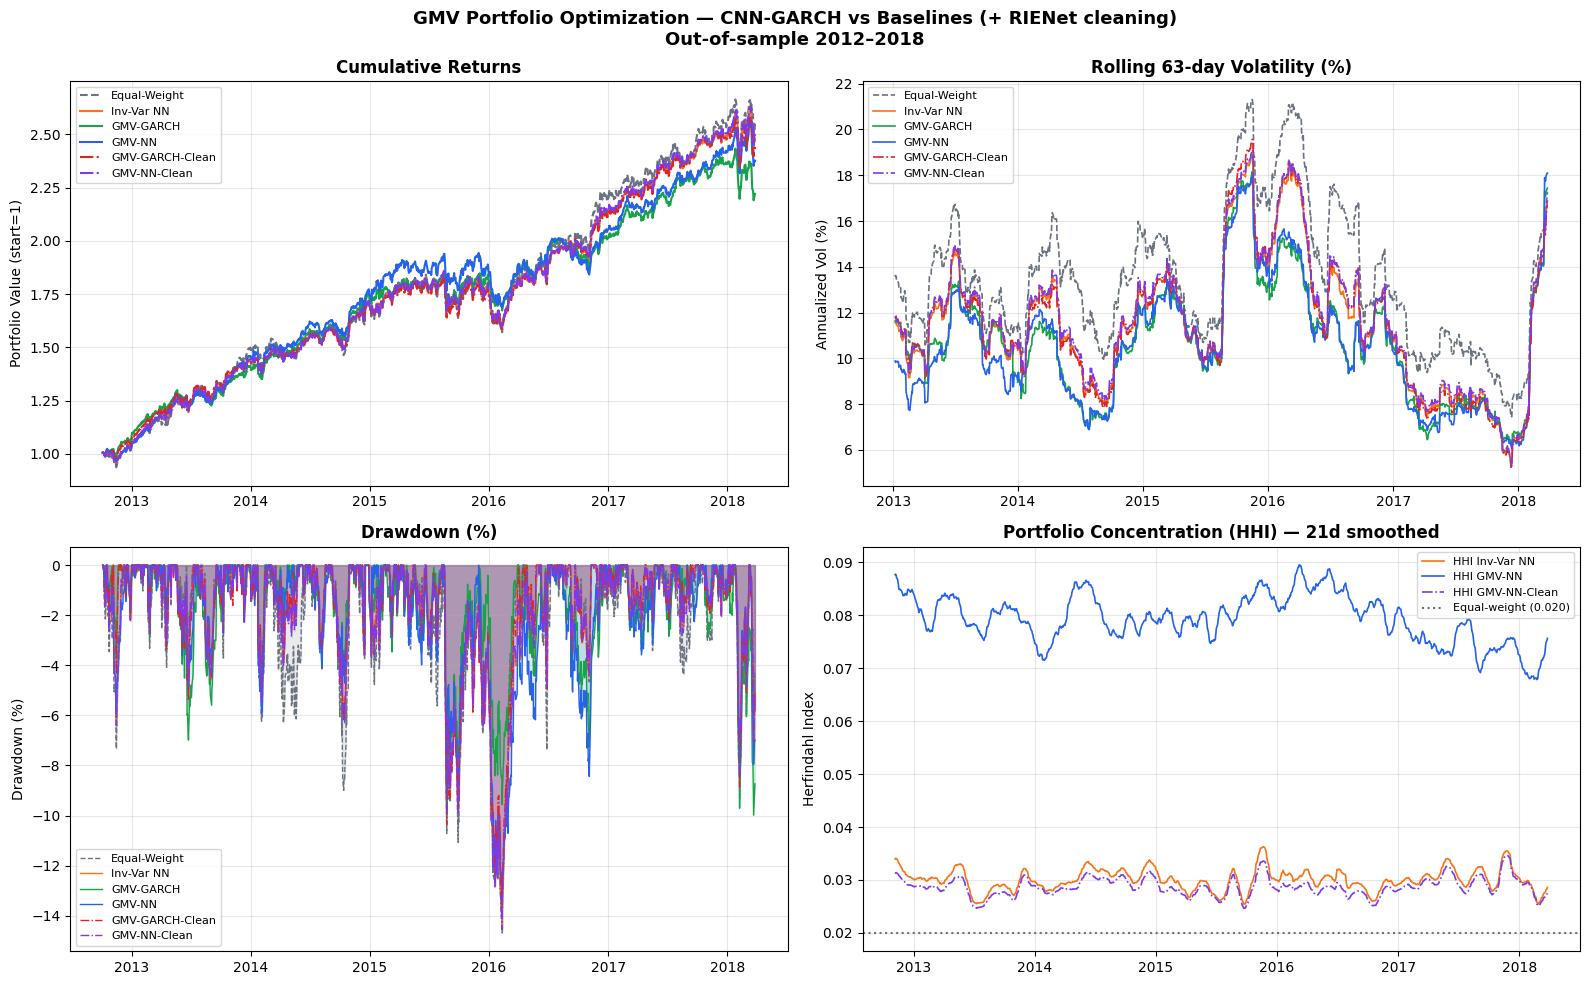

Figure saved: gmv_results.png


In [15]:
# ── Colors ────────────────────────────────────────────────────────────────────
_BLUE   = '#2563EB'
_ORANGE = '#F97316'
_GREEN  = '#16A34A'
_RED    = '#DC2626'
_GREY   = '#6B7280'
_PURPLE = '#7C3AED'

strategies = {
    'Equal-Weight'    : (r_eq,              _GREY,   '--'),
    'Inv-Var NN'      : (r_inv_nn,          _ORANGE, '-'),
    'GMV-GARCH'       : (r_gmv_arch,        _GREEN,  '-'),
    'GMV-NN'          : (r_gmv_nn,          _BLUE,   '-'),
    'GMV-GARCH-Clean' : (r_gmv_arch_clean,  _RED,    '-.'),
    'GMV-NN-Clean'    : (r_gmv_nn_clean,    _PURPLE, '-.'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('GMV Portfolio Optimization — CNN-GARCH vs Baselines (+ RIENet cleaning)\nOut-of-sample 2012–2018',
             fontsize=13, fontweight='bold')

# ── 1. Cumulative returns ─────────────────────────────────────────────────────
ax = axes[0, 0]
for name, (r, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    ax.plot(cum.index, cum.values, color=col, linestyle=ls, linewidth=1.5, label=name)
ax.set_title('Cumulative Returns', fontweight='bold')
ax.set_ylabel('Portfolio Value (start=1)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── 2. Rolling 63-day volatility ──────────────────────────────────────────────
ax = axes[0, 1]
for name, (r, col, ls) in strategies.items():
    roll_vol = pd.Series(r, index=test_dates).rolling(63).std() * np.sqrt(252) * 100
    ax.plot(roll_vol.index, roll_vol.values, color=col, linestyle=ls, linewidth=1.2, label=name)
ax.set_title('Rolling 63-day Volatility (%)', fontweight='bold')
ax.set_ylabel('Annualized Vol (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── 3. Drawdown ───────────────────────────────────────────────────────────────
ax = axes[1, 0]
for name, (r, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd.values, 0, alpha=0.15, color=col)
    ax.plot(dd.index, dd.values, color=col, linestyle=ls, linewidth=1.0, label=name)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── 4. Weight concentration: GMV-NN vs GMV-NN-Clean ──────────────────────────
ax = axes[1, 1]
hhi_inv = pd.Series((w_inv_nn**2).sum(axis=1), index=test_dates)
hhi_gmv = pd.Series((w_gmv_nn**2).sum(axis=1), index=test_dates)
hhi_gmv_clean = pd.Series((w_gmv_nn_clean**2).sum(axis=1), index=test_dates)
ax.plot(hhi_inv.index, hhi_inv.rolling(21).mean(), color=_ORANGE, label='HHI Inv-Var NN', linewidth=1.2)
ax.plot(hhi_gmv.index, hhi_gmv.rolling(21).mean(), color=_BLUE,   label='HHI GMV-NN',    linewidth=1.2)
ax.plot(hhi_gmv_clean.index, hhi_gmv_clean.rolling(21).mean(), color=_PURPLE, label='HHI GMV-NN-Clean', linewidth=1.2, linestyle='-.')
ax.axhline(1/N_STOCKS, color=_GREY, linestyle=':', label=f'Equal-weight ({1/N_STOCKS:.3f})')
ax.set_title('Portfolio Concentration (HHI) — 21d smoothed', fontweight='bold')
ax.set_ylabel('Herfindahl Index')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gmv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gmv_results.png')

In [16]:
N_STOCKS

50

## 10. GMV-NN vs Inv-Var NN — Direct Comparison

In [ ]:
# ── Compare ALL strategies ────────────────────────────────────────────────────
all_strategies = {
    'Equal-Weight'    : (r_eq,              w_eq),
    'Inv-Var NN'      : (r_inv_nn,          w_inv_nn),
    'GMV-GARCH'       : (r_gmv_arch,        w_gmv_arch),
    'GMV-NN'          : (r_gmv_nn,          w_gmv_nn),
    'GMV-GARCH-Clean' : (r_gmv_arch_clean,  w_gmv_arch_clean),
    'GMV-NN-Clean'    : (r_gmv_nn_clean,    w_gmv_nn_clean),
}

# Metrics table
all_metrics = {name: financial_metrics(r) for name, (r, _) in all_strategies.items()}

print('=' * 100)
print('FULL COMPARISON — ALL STRATEGIES (Out-of-sample)')
print('=' * 100)

header = f"{'Metric':<22}" + ''.join(f'{name:>16}' for name in all_metrics)
print(header)
print('-' * len(header))

metric_names = list(next(iter(all_metrics.values())).keys())
for m in metric_names:
    vals = [all_metrics[name][m] for name in all_metrics]
    row = f'{m:<22}' + ''.join(f'{v:>16}' for v in vals)

    # Highlight best
    if 'Vol' in m or 'Drawdown' in m:
        best_name = min(all_metrics, key=lambda n: all_metrics[n][m])
    else:
        best_name = max(all_metrics, key=lambda n: all_metrics[n][m])
    print(row + f'   ← best: {best_name}')

# Weight concentration
print(f'\n{"─" * 100}')
print(f'{"WEIGHT CONCENTRATION":<22}' + ''.join(f'{name:>16}' for name in all_strategies))
print('-' * 100)

hhi_row = f'{"Mean HHI":<22}'
max_w_row = f'{"Mean Max Weight":<22}'
for name, (_, w) in all_strategies.items():
    hhi_row  += f'{(w**2).sum(axis=1).mean():>16.4f}'
    max_w_row += f'{w.max(axis=1).mean():>15.1%} '

print(hhi_row)
print(max_w_row)

# Pairwise improvement: each "Clean" vs its raw counterpart
print(f'\n{"=" * 80}')
print('EFFECT OF RIENet CLEANING')
print('=' * 80)
for raw_name, clean_name in [('GMV-GARCH', 'GMV-GARCH-Clean'), ('GMV-NN', 'GMV-NN-Clean')]:
    m_raw   = all_metrics[raw_name]
    m_clean = all_metrics[clean_name]
    print(f'\n  {clean_name} vs {raw_name}:')
    for k in metric_names:
        v1, v2 = m_raw[k], m_clean[k]
        if 'Vol' in k or 'Drawdown' in k:
            imp = f'{v1 - v2:+.2f}  (lower is better)' if v2 < v1 else f'{v1 - v2:+.2f}'
        else:
            imp = f'{v2 - v1:+.4f}  (higher is better)' if v2 > v1 else f'{v2 - v1:+.4f}'
        print(f'    {k:<22} {imp}')